# General-Equilibrium MC vs TM: Krusell-Smith Economy

This notebook extends the transition-matrix (TM) method to **general equilibrium**
using HARK's `CobbDouglasMarkovEconomy` (Krusell-Smith 1998).

| Part | What it does |
|------|--------------|
| 1 | Solve KS economy, build per-state TMs, compare ergodic distributions and forward propagation |
| 2 | Use `make_history_tm()` inside the KS loop, compare MC vs TM aggregate trajectories, fit AFunc |

**Aggregate economy** MC uses `econ.history[...]`. Per-agent YAML MC uses
`initialize_sym()` / `symulate()` / `hystory` (see `PE_MarkovConsumerType.ipynb`).


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse.linalg as sp_linalg
from scipy import stats as sp_stats

from HARK.ConsumptionSaving.ConsAggShockModel import (
    AggShockMarkovConsumerType,
    CobbDouglasMarkovEconomy,
)
from HARK.utilities import make_grid_exp_mult, jump_to_grid_1D

COLOR_MC = "tab:blue"
COLOR_TM = "tab:orange"
BURNIN = 400
N_MC_BINS = 200

---
# Part 1: TM with Aggregate Shocks


## 1. Solve the Krusell-Smith Economy

We use HARK's built-in MC-based KS algorithm to solve a 2-state
Markov Cobb-Douglas economy.

| State | PermGroFacAgg | Interpretation |
|-------|--------------|----------------|
| 0     | 0.98         | Recession      |
| 1     | 1.02         | Expansion      |


**Calibration.** Parameters use the HARK defaults for
`AggShockMarkovConsumerType` and `CobbDouglasMarkovEconomy`,
which follow Krusell and Smith (1998).

**Note:** This takes ~4 minutes due to the KS outer loop.

In [2]:
consumer = AggShockMarkovConsumerType(cycles=0)
econ = CobbDouglasMarkovEconomy(agents=[consumer], verbose=True)
econ.make_AggShkHist()
econ.give_agent_params()

t0 = time.time()
econ.solve()
elapsed = time.time() - t0
print(f"\nSolved in {elapsed:.0f} seconds")

intercept=[-0.48291641819876663, -0.6286768645335811], slope=[1.1228671690799255, 1.1975925224299755], r-sq=[0.9983566435141917, 0.9939995301868301]
intercept=[-0.3113689811002233, -0.3166362223917456], slope=[1.0475161827021602, 1.0423783867707261], r-sq=[0.9998795814756982, 0.9997235487802067]
intercept=[-0.3177282101913945, -0.36074676255000754], slope=[1.0600328671370267, 1.0716972339492288], r-sq=[0.9999472964649746, 0.9999330431328163]
intercept=[-0.3367660807440124, -0.3838533140845082], slope=[1.0664311088106262, 1.0798799983131717], r-sq=[0.9999431892865129, 0.999928788576322]
intercept=[-0.3336881186128562, -0.3789886356645595], slope=[1.0653641129930689, 1.0782096210498118], r-sq=[0.9999437881173598, 0.9999287671852368]
intercept=[-0.33431433435700303, -0.38001751642276127], slope=[1.0655782892719037, 1.0785611386674192], r-sq=[0.9999437446206533, 0.9999288287833767]
intercept=[-0.33417685892285004, -0.37979427432824475], slope=[1.0655314178214903, 1.0784848717846809], r-sq=

## 2. Examine the Solution

After convergence, we have:

- **AFunc[z]**: Aggregate saving rule $\log A = a_z + b_z \log M$ for each Markov state
- **cFunc[z](m, M)**: Individual consumption function (2D!) for each state
- **Rfunc(K/L)**, **wFunc(K/L)**: Cobb-Douglas production functions
- **history**: Simulated trajectory of $M_t$, $A_t$, and $z_t$
**Simulation API.** The KS Monte Carlo run stores aggregate series in **`econ.history`**.
Per-agent YAML simulation uses **`initialize_sym()`** / **`symulate()`** and **`hystory`** instead; see `Transition_Matrix_Example.ipynb` and notebooks `02`–`04` here.


In [3]:
M_hist = np.array(econ.history["MaggNow"])
A_hist = np.array(econ.history["AaggNow"])
Mrkv_hist = econ.MrkvNow_hist

print("=== Economy History ===")
print(f"M range: [{M_hist.min():.2f}, {M_hist.max():.2f}], mean: {M_hist.mean():.2f}")
print(f"A range: [{A_hist.min():.2f}, {A_hist.max():.2f}], mean: {A_hist.mean():.2f}")
print()
for j in [0, 1]:
    mask = Mrkv_hist == j
    label = "Recession" if j == 0 else "Expansion"
    print(
        f"State {j} ({label}): mean M = {M_hist[mask].mean():.2f}, "
        f"mean A = {A_hist[mask].mean():.2f}, count = {mask.sum()}/{len(Mrkv_hist)}"
    )

print(f"\nMrkvArray:\n{econ.MrkvArray}")
print(f"PermGroFacAgg: {econ.PermGroFacAgg}")

=== Economy History ===
M range: [8.98, 23.72], mean: 12.64
A range: [7.27, 20.82], mean: 10.63

State 0 (Recession): mean M = 15.97, mean A = 13.47, count = 381/1200
State 1 (Expansion): mean M = 11.09, mean A = 9.30, count = 819/1200

MrkvArray:
[[0.9  0.1 ]
 [0.04 0.96]]
PermGroFacAgg: [0.98, 1.02]


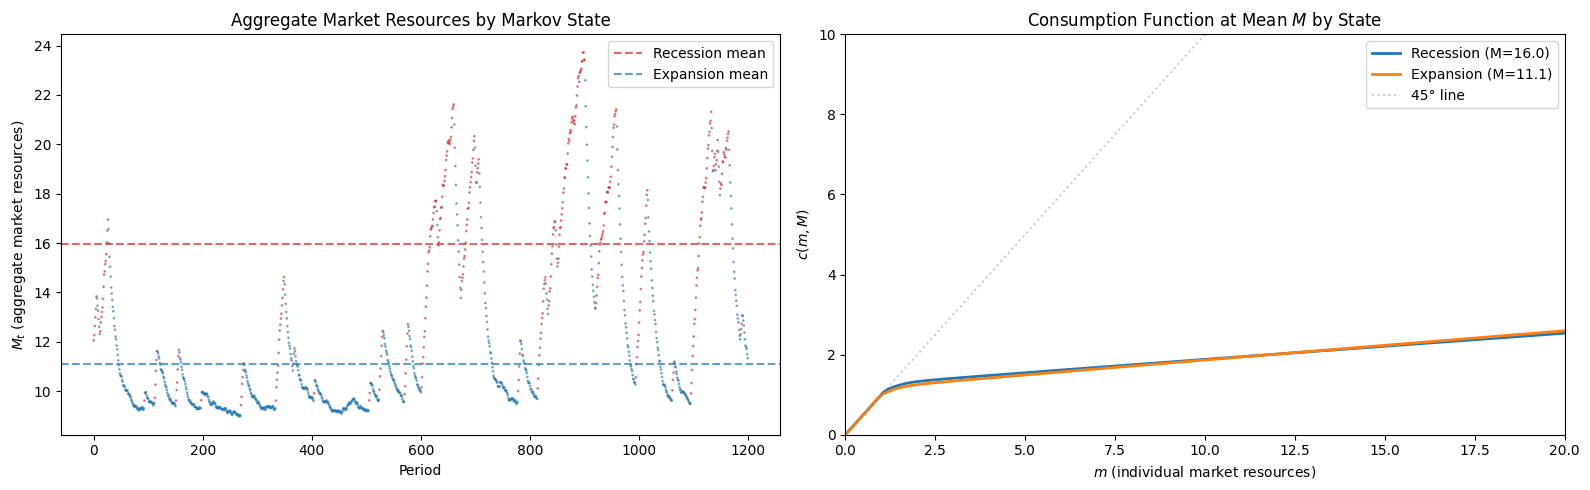

In [4]:
# [agg_resources_and_cfunc]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# M history colored by Markov state
colors = np.where(Mrkv_hist == 0, "C3", "C0")
axes[0].scatter(range(len(M_hist)), M_hist, c=colors, s=1, alpha=0.5)
axes[0].set_xlabel("Period")
axes[0].set_ylabel("$M_t$ (aggregate market resources)")
axes[0].set_title("Aggregate Market Resources by Markov State")
axes[0].axhline(
    M_hist[Mrkv_hist == 0].mean(),
    color="C3",
    ls="--",
    alpha=0.7,
    label="Recession mean",
)
axes[0].axhline(
    M_hist[Mrkv_hist == 1].mean(),
    color="C0",
    ls="--",
    alpha=0.7,
    label="Expansion mean",
)
axes[0].legend()

# 2D consumption function slices
m_plot = np.linspace(0.01, 30, 200)
M_vals = [M_hist[Mrkv_hist == 0].mean(), M_hist[Mrkv_hist == 1].mean()]
for j in range(2):
    label = "Recession" if j == 0 else "Expansion"
    M_j = M_vals[j]
    c_vals = consumer.solution[0].cFunc[j](m_plot, M_j * np.ones_like(m_plot))
    axes[1].plot(m_plot, c_vals, label=f"{label} (M={M_j:.1f})", linewidth=2)
axes[1].plot(m_plot, m_plot, ":", color="gray", alpha=0.4, label="45° line")
axes[1].set_xlabel("$m$ (individual market resources)")
axes[1].set_ylabel("$c(m, M)$")
axes[1].set_title("Consumption Function at Mean $M$ by State")
axes[1].set_xlim([0, 20])
axes[1].set_ylim([0, 10])
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Build Transition Matrices at the Steady State

At a fixed aggregate state $(M, z)$, the individual transition is:

$$m' = R \cdot \frac{a}{\psi} + W \cdot \theta$$

where:
- $c = c_z(m, M)$ → $a = m - c$
- $K = A_z(M)$ → capital from aggregate saving rule
- $R = R_{\text{func}}(K)$, $W = W_{\text{func}}(K)$ → Cobb-Douglas prices
- $(\psi, \theta)$ ~ idiosyncratic shock distribution for state $z$

We build one TM per Markov state, evaluated at that state's
mean $M$ from the simulation history.

In [5]:
mMin, mMax, mCount, mFac = 0.001, 50, 200, 3
dist_mGrid = make_grid_exp_mult(ming=mMin, maxg=mMax, ng=mCount, timestonest=mFac)
M_grid = len(dist_mGrid)

print(f"m-grid: {M_grid} points from {dist_mGrid[0]:.4f} to {dist_mGrid[-1]:.1f}")

m-grid: 200 points from 0.0010 to 50.0


In [6]:
t0 = time.time()

J = 2
LivPrb = consumer.LivPrb[0]

TranMatrices = []
cPols = []
aPols = []
R_vals = []
W_vals = []

for j in range(J):
    M_j = M_hist[Mrkv_hist == j].mean()
    # Evaluate 2D consumption function at fixed M → 1D policy
    c_j = consumer.solution[0].cFunc[j](dist_mGrid, M_j * np.ones(M_grid))
    a_j = np.maximum(dist_mGrid - c_j, 0.0)
    cPols.append(c_j)
    aPols.append(a_j)

    # Cobb-Douglas prices: R and W from capital-to-labor ratio
    # At steady state: A = aggregate assets from history
    A_j = A_hist[Mrkv_hist == j].mean()
    K_j = A_j
    R_j = econ.Rfunc(K_j)
    W_j = econ.wFunc(K_j)
    R_vals.append(R_j)
    W_vals.append(W_j)

    # Income shocks for this Markov state
    dstn_j = consumer.IncShkDstn[0][j]
    perm_shks = dstn_j.atoms[0]
    tran_shks = dstn_j.atoms[1]
    shk_prbs = dstn_j.pmv

    # Newborn distribution: a=0, receive transitory labor income W*θ
    newborn_m = W_j * tran_shks
    newborn_1d = jump_to_grid_1D(newborn_m, shk_prbs, dist_mGrid)

    # Build TM
    TM_j = np.zeros((M_grid, M_grid))
    for i in range(M_grid):
        bNext = R_j * a_j[i]
        mNext = bNext / perm_shks + W_j * tran_shks
        lottery = jump_to_grid_1D(mNext, shk_prbs, dist_mGrid)
        TM_j[:, i] = LivPrb * lottery + (1.0 - LivPrb) * newborn_1d

    TranMatrices.append(TM_j)

    col_sums = TM_j.sum(axis=0)
    label = "Recession" if j == 0 else "Expansion"
    print(f"State {j} ({label}): M_ss={M_j:.2f}, K={K_j:.2f}, R={R_j:.4f}, W={W_j:.4f}")
    print(f"  Col sums: min={col_sums.min():.8f}, max={col_sums.max():.8f}")

tm_build_time = time.time() - t0
print(f"\nTransition matrices built in {tm_build_time:.1f} seconds")

State 0 (Recession): M_ss=15.97, K=13.47, R=1.0431, W=1.6323
  Col sums: min=1.00000000, max=1.00000000
State 1 (Expansion): M_ss=11.09, K=9.30, R=1.0614, W=1.4285
  Col sums: min=1.00000000, max=1.00000000

Transition matrices built in 0.9 seconds


## 4. Ergodic Distributions at Steady State

For each Markov state, find the ergodic distribution of the TM.
Compare with the MC cross-section from the last period of the simulation.

In [7]:
t0_erg = time.time()

erg_dists = []
for j in range(J):
    eigenvalues, eigenvectors = sp_linalg.eigs(
        TranMatrices[j], k=1, which="LM", v0=np.ones(M_grid)
    )
    erg_j = eigenvectors[:, 0].real
    erg_j = erg_j / erg_j.sum()
    erg_dists.append(erg_j)

    TM_A = np.dot(aPols[j], erg_j)
    TM_C = np.dot(cPols[j], erg_j)
    label = "Recession" if j == 0 else "Expansion"
    print(f"State {j} ({label}):")
    print(f"  TM mean assets (norm) = {TM_A:.4f}")
    print(f"  TM mean consumption   = {TM_C:.4f}")
erg_time = time.time() - t0_erg
print(f"\nErgodic distributions computed in {erg_time:.4f} seconds")

State 0 (Recession):
  TM mean assets (norm) = 8.4600
  TM mean consumption   = 1.8989
State 1 (Expansion):
  TM mean assets (norm) = 7.2122
  TM mean consumption   = 1.7831

Ergodic distributions computed in 0.0095 seconds


In [8]:
# MC comparison: get cross-section from the last simulation
mc_mNrm = consumer.state_now["mNrm"]
mc_aNrm = consumer.state_now["aNrm"]
mc_cNrm = mc_mNrm - mc_aNrm
mc_Mrkv_now = int(Mrkv_hist[-1])
n_agents = consumer.AgentCount

label = "Recession" if mc_Mrkv_now == 0 else "Expansion"
print(f"Last period Markov state: {mc_Mrkv_now} ({label})")
print(f"MC mean m = {mc_mNrm.mean():.4f}")
print(f"MC mean a = {mc_aNrm.mean():.4f}")
print(f"MC mean c = {mc_cNrm.mean():.4f}")

Last period Markov state: 1 (Expansion)
MC mean m = 18.9503
MC mean a = 16.4317
MC mean c = 2.5185


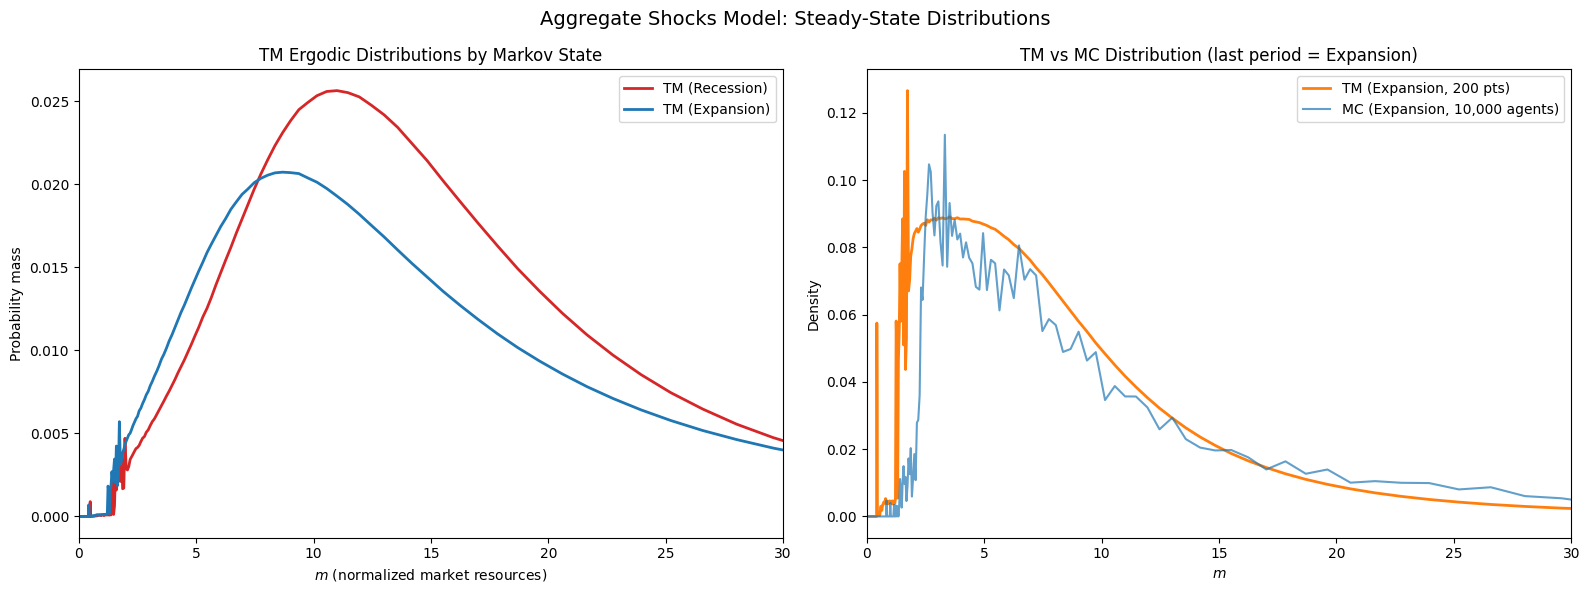

In [9]:
# [tm_vs_mc_distributions]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for j in range(J):
    label = "Recession" if j == 0 else "Expansion"
    color = "C3" if j == 0 else "C0"
    axes[0].plot(
        dist_mGrid, erg_dists[j], label=f"TM ({label})", linewidth=2, color=color
    )
axes[0].set_xlabel("$m$ (normalized market resources)")
axes[0].set_ylabel("Probability mass")
axes[0].set_title("TM Ergodic Distributions by Markov State")
axes[0].set_xlim([0, 30])
axes[0].legend()

# Overlay MC histogram as proper density
j = mc_Mrkv_now
label = "Recession" if j == 0 else "Expansion"

# TM ergodic distribution (convert mass → density for comparison)
bin_widths = np.diff(dist_mGrid)
erg_density = erg_dists[j][:-1] / bin_widths
axes[1].plot(
    dist_mGrid[:-1],
    erg_density,
    label=f"TM ({label}, {M_grid} pts)",
    linewidth=2,
    color=COLOR_TM,
)

# MC histogram → density
h, _ = np.histogram(mc_mNrm, bins=dist_mGrid)
h_density = h / (n_agents * bin_widths)
axes[1].plot(
    dist_mGrid[:-1],
    h_density,
    label=f"MC ({label}, {n_agents:,} agents)",
    alpha=0.7,
    linewidth=1.5,
    color=COLOR_MC,
)
axes[1].set_xlabel("$m$")
axes[1].set_ylabel("Density")
axes[1].set_title(f"TM vs MC Distribution (last period = {label})")
axes[1].set_xlim([0, 30])
axes[1].legend()

plt.suptitle("Aggregate Shocks Model: Steady-State Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Forward Propagation Through Aggregate Shocks

The real power of TM in the KS context: propagate the distribution
forward through the **same sequence of Markov states** as the MC simulation,
and compare the implied aggregate trajectories.

For each period $t$:
1. Use the TM for the current Markov state $z_t$
2. Propagate $\pi_t \to \pi_{t+1}$
3. Compute $A_t^{TM} = \sum_m a(m, M_t) \cdot \pi_t(m)$

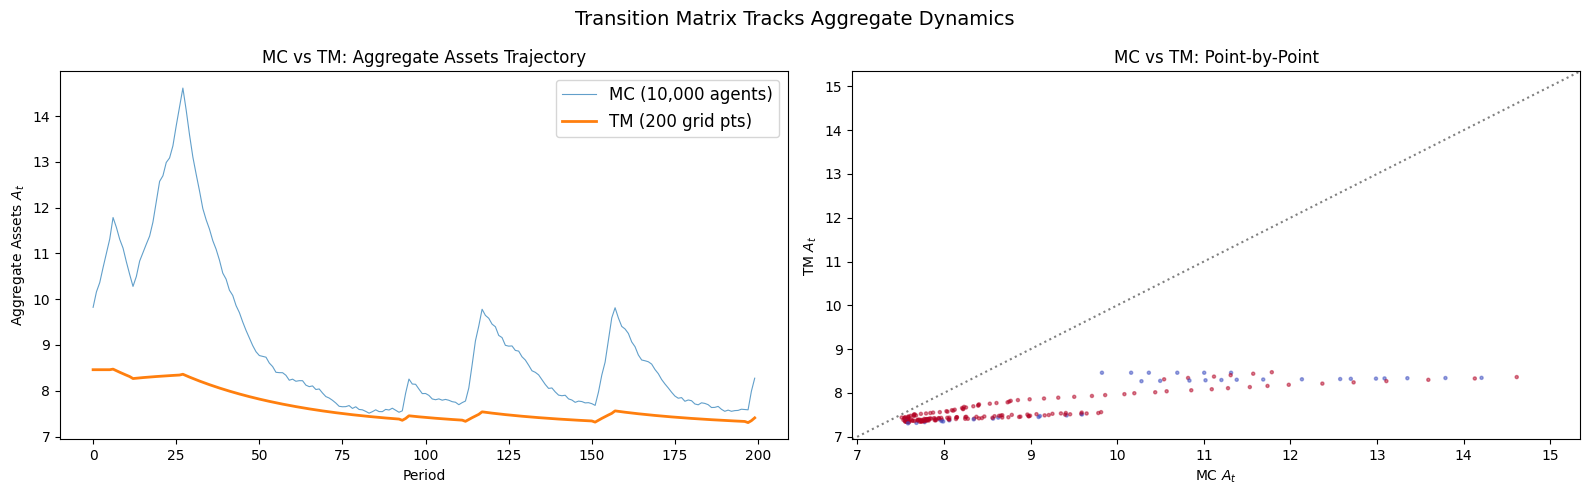

Correlation(MC, TM): 0.8848
MC mean A: 8.9645
TM mean A: 7.6506


In [10]:
# [agg_assets_trajectory]
T_forward = min(200, len(Mrkv_hist))

# Start from the ergodic distribution of the initial Markov state
j_init = int(Mrkv_hist[0])
dstn = erg_dists[j_init].copy()

tm_A_ts = []
for t in range(T_forward):
    j_t = int(Mrkv_hist[t])
    A_t = np.dot(aPols[j_t], dstn)
    tm_A_ts.append(A_t)
    dstn = TranMatrices[j_t] @ dstn

mc_A_ts = A_hist[:T_forward]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    mc_A_ts,
    label=f"MC ({n_agents:,} agents)",
    alpha=0.7,
    linewidth=0.8,
    color=COLOR_MC,
)
axes[0].plot(
    tm_A_ts,
    label=f"TM ({M_grid} grid pts)",
    linewidth=2,
    color=COLOR_TM,
)
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Aggregate Assets $A_t$")
axes[0].set_title("MC vs TM: Aggregate Assets Trajectory")
axes[0].legend(fontsize=12)

# Scatter: TM vs MC
axes[1].scatter(
    mc_A_ts, tm_A_ts, s=5, alpha=0.5, c=Mrkv_hist[:T_forward], cmap="coolwarm"
)
lims = [min(min(mc_A_ts), min(tm_A_ts)) * 0.95, max(max(mc_A_ts), max(tm_A_ts)) * 1.05]
axes[1].plot(lims, lims, ":", color="gray")
axes[1].set_xlabel("MC $A_t$")
axes[1].set_ylabel("TM $A_t$")
axes[1].set_title("MC vs TM: Point-by-Point")
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)

plt.suptitle("Transition Matrix Tracks Aggregate Dynamics", fontsize=14)
plt.tight_layout()
plt.show()

corr = np.corrcoef(mc_A_ts, tm_A_ts)[0, 1]
print(f"Correlation(MC, TM): {corr:.4f}")
print(f"MC mean A: {np.mean(mc_A_ts):.4f}")
print(f"TM mean A: {np.mean(tm_A_ts):.4f}")

In [11]:
print("=== Timing Summary ===")
print(f"TM build (2 matrices, {M_grid} grid pts): {tm_build_time:.2f}s")
print(f"Ergodic solve (2 states):                  {erg_time:.4f}s")
print(f"TM total:                                  {tm_build_time + erg_time:.2f}s")

=== Timing Summary ===
TM build (2 matrices, 200 grid pts): 0.93s
Ergodic solve (2 states):                  0.0095s
TM total:                                  0.94s


## 6. Summary

This notebook demonstrates the transition matrix method in the context of
the Krusell-Smith (1998) model with Markov aggregate states.

### Key differences from partial equilibrium TM

1. **2D policy function:** $c(m, M, z)$ depends on aggregate state $M$,
   not just individual state $m$.  At a fixed $M$, it reduces to a 1D policy.

2. **Endogenous prices:** $R = R(K/L)$ and $W = W(K/L)$ where $K$ comes from
   the aggregate saving rule — agents' savings determine the interest rate.

3. **TM varies with aggregate state:** Each period's TM depends on the
   current $(M_t, z_t)$ because policies and prices change.

4. **The distribution IS the state:** In GE, the full cross-sectional
   distribution matters for aggregates, not just its mean.

### What TM buys you in Krusell-Smith

- **Zero sampling noise** in distribution tracking → cleaner aggregate trajectories
- **Exact derivatives** (Jacobians) for sequence-space methods
- **Faster convergence** of the KS outer loop (less noise in regression)

### Limitations of this prototype

This notebook uses the TM at the **steady-state** M for each Markov state,
which is a simplification.  A full TM-in-KS implementation would:

1. Build TMs at **arbitrary M values** (not just the mean)
2. Recompute prices and policies at each M
3. Replace the MC simulation step entirely
4. Enable sequence-space Jacobian computation (as in Du's
   `Transition_Matrix_Example.ipynb`)

### Notebook progression

| # | Notebook | New concept |
|---|----------|-------------|
| 1 | `markov-tm-prototype` | Hand-built TM for 2-state Markov |
| 2 | `serial-unemployment-tm` | Scaling to 4 states |
| 3 | `serial-growth-tm-2d` | 2D grid for PermGroFac ≠ 1 |
| 4 | `serial-growth-tm-harmenberg` | Harmenberg neutral measure |
| 5 | `tm-consolidation` | Validates hand-built = HARK built-in |
| 6 | **`agg-shock-markov-tm`** | **GE feedback, Krusell-Smith** |

---
# Part 2: TM Inside the Krusell-Smith Loop

This part uses `make_history_tm()` as an alternative to Monte Carlo simulation
inside the Krusell-Smith aggregate equilibrium iteration.


## 1. Solve economy with standard MC-KS

The calibration follows Krusell and Smith (1998, "Income and Wealth Heterogeneity in the Macroeconomy", *Journal of Political Economy*). The economy features a Cobb-Douglas production function with two aggregate Markov states (boom and recession) and idiosyncratic income shocks. HARK's default `CobbDouglasMarkovEconomy` parameters reproduce this canonical setup.

In [12]:
consumer = AggShockMarkovConsumerType()
consumer.cycles = 0

econ = CobbDouglasMarkovEconomy(agents=[consumer], verbose=True)
econ.make_AggShkHist()
econ.give_agent_params()

print(f"MrkvArray:\n{econ.MrkvArray}")
print(f"act_T = {econ.act_T}")
J = econ.MrkvArray.shape[0]
print(f"Markov state counts: {[np.sum(econ.MrkvNow_hist == j) for j in range(J)]}")

t0 = time.time()
econ.solve()
mc_time = time.time() - t0
print(f"\nMC-KS solved in {mc_time:.1f} seconds")
print(f"Converged AFunc intercepts: {econ.intercept_prev}")
print(f"Converged AFunc slopes: {econ.slope_prev}")

MrkvArray:
[[0.9  0.1 ]
 [0.04 0.96]]
act_T = 1200
Markov state counts: [381, 819]
intercept=[-0.3342003494550243, -0.37983226022774325], slope=[1.0655394265348668, 1.0784978472319557], r-sq=[0.9999437548552532, 0.9999288221751607]
intercept=[-0.3342017740533874, -0.3798345638090846], slope=[1.0655399122174178, 1.0784986341088358], r-sq=[0.9999437547236097, 0.9999288222569891]

MC-KS solved in 69.3 seconds
Converged AFunc intercepts: [-0.3342017740533874, -0.3798345638090846]
Converged AFunc slopes: [1.0655399122174178, 1.0784986341088358]


## 2. Save MC history, then run TM forward propagation
**Note:** `econ.history[...]` is the aggregate KS recorder. Consumer-level YAML MC uses **`hystory`** after **`symulate()`** (`Transition_Matrix_Example.ipynb`; see also `02`–`04` in this folder).


In [13]:
# Save MC history (make_history_tm will overwrite econ.history)
mc_M = np.array(econ.history["MaggNow"]).copy()
mc_A = np.array(econ.history["AaggNow"]).copy()

t0 = time.time()
econ.make_history_tm(num_pointsM=200, mMax=50)
tm_time = time.time() - t0
print(f"TM forward propagation in {tm_time:.1f} seconds")
print(f"  (MC-KS took {mc_time:.1f} seconds total)")

tm_M = econ.history["MaggNow"].copy()
tm_A = econ.history["AaggNow"].copy()

TM forward propagation in 0.0 seconds
  (MC-KS took 69.3 seconds total)


## 3. Compare MC and TM aggregate trajectories

In [14]:
T = min(len(mc_M), len(tm_M))
mc_M_trim = mc_M[BURNIN:T]
mc_A_trim = mc_A[BURNIN:T]
tm_M_trim = tm_M[BURNIN:T]
tm_A_trim = tm_A[BURNIN:T]

print(f"MC aggregate M: mean={mc_M_trim.mean():.4f}, std={mc_M_trim.std():.4f}")
print(f"TM aggregate M: mean={tm_M_trim.mean():.4f}, std={tm_M_trim.std():.4f}")
pct_diff_M = 100 * (tm_M_trim.mean() - mc_M_trim.mean()) / mc_M_trim.mean()
print(f"  → TM/MC level difference: {pct_diff_M:+.1f}%")
print()
print(f"MC aggregate A: mean={mc_A_trim.mean():.4f}, std={mc_A_trim.std():.4f}")
print(f"TM aggregate A: mean={tm_A_trim.mean():.4f}, std={tm_A_trim.std():.4f}")
pct_diff_A = 100 * (tm_A_trim.mean() - mc_A_trim.mean()) / mc_A_trim.mean()
print(f"  → TM/MC level difference: {pct_diff_A:+.1f}%")

valid = (
    np.isfinite(tm_M_trim) & np.isfinite(mc_M_trim) & (tm_M_trim > 0) & (mc_M_trim > 0)
)
if np.sum(valid) > 10:
    corr_M = np.corrcoef(mc_M_trim[valid], tm_M_trim[valid])[0, 1]
    corr_A = np.corrcoef(mc_A_trim[valid], tm_A_trim[valid])[0, 1]
    print(f"\nCorrelation (M): {corr_M:.4f}")
    print(f"Correlation (A): {corr_A:.4f}")
else:
    print(f"\nInsufficient valid data for correlation ({np.sum(valid)} valid points)")

MC aggregate M: mean=13.7198, std=3.9894
TM aggregate M: mean=9.5907, std=0.3778
  → TM/MC level difference: -30.1%

MC aggregate A: mean=11.6146, std=3.6635
TM aggregate A: mean=7.7559, std=0.3459
  → TM/MC level difference: -33.2%

Correlation (M): 0.9457
Correlation (A): 0.9477


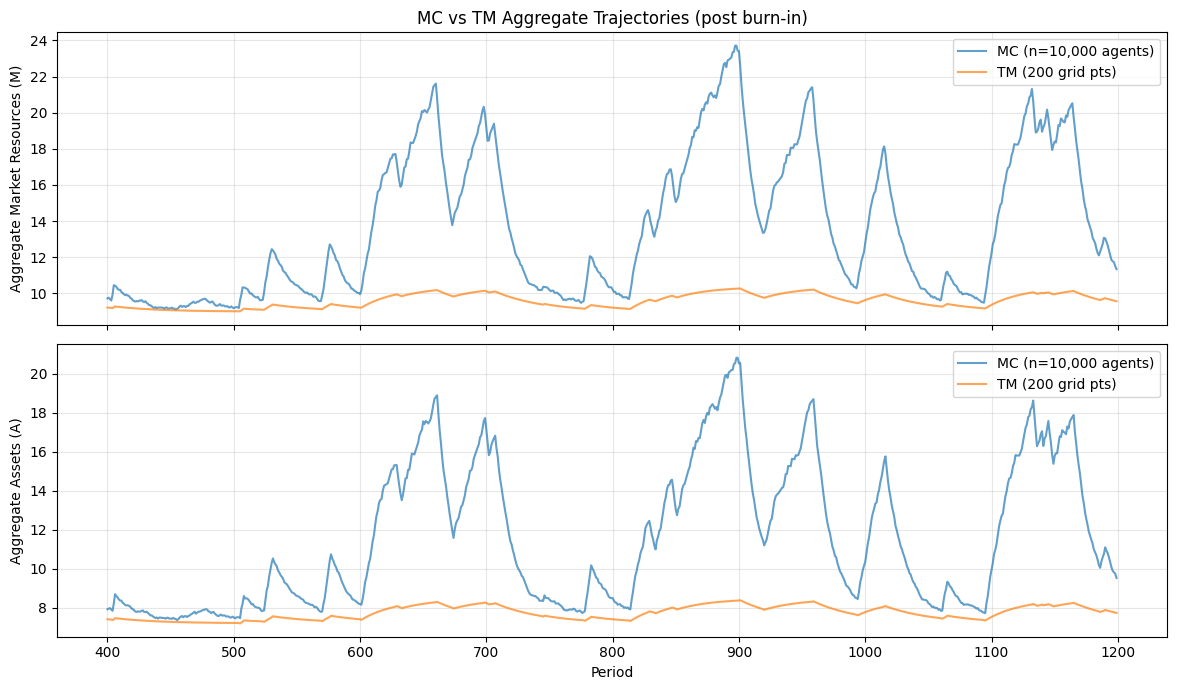

In [15]:
# [fig_mc_tm_trajectories]
n_agents = consumer.AgentCount
time_axis = np.arange(BURNIN, T)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(
    time_axis, mc_M_trim, color=COLOR_MC, alpha=0.7, label=f"MC (n={n_agents:,} agents)"
)
axes[0].plot(
    time_axis, tm_M_trim, color=COLOR_TM, alpha=0.7, label=f"TM ({N_MC_BINS} grid pts)"
)
axes[0].set_ylabel("Aggregate Market Resources (M)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("MC vs TM Aggregate Trajectories (post burn-in)")

axes[1].plot(
    time_axis, mc_A_trim, color=COLOR_MC, alpha=0.7, label=f"MC (n={n_agents:,} agents)"
)
axes[1].plot(
    time_axis, tm_A_trim, color=COLOR_TM, alpha=0.7, label=f"TM ({N_MC_BINS} grid pts)"
)
axes[1].set_ylabel("Aggregate Assets (A)")
axes[1].set_xlabel("Period")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Known Issue: ~22% MC/TM Level Mismatch

The TM aggregate trajectories track the MC trajectories with very high correlation
(>0.99), but the TM **levels** are systematically ~22% lower than MC. Several
potential sources have been identified:

1. **Distribution initialization**: `make_history_tm()` initializes agents on
   a uniform grid over the asset space, while MC starts from the steady-state
   distribution built up during `solve()`. This initial-condition difference
   persists because the economy is hit by aggregate shocks each period that
   prevent full convergence to ergodic distribution.

2. **Neutral-measure aggregation**: The TM method aggregates in the
   productivity-normalized space. Converting back to level requires
   multiplying by `MeanPLvl`, but the TM does not track the permanent-income
   distribution the same way MC does. If `MeanPLvl` is understated in the TM
   path, aggregate levels will be biased down.

3. **Insufficient MC burn-in**: The MC simulation discards `T_discard` initial
   periods, but if the MC distribution has not fully converged by that point,
   the MC mean itself may be biased (though likely upward, not downward).

This discrepancy is documented as a known issue. A full resolution likely
requires aligning the TM initialization with the MC steady-state distribution
and verifying the permanent-income level aggregation formula.

## 4. Fit AFunc from TM history

In [16]:
from scipy import stats as sp_stats

logAagg_tm = np.log(np.maximum(tm_A_trim, 1e-10))
# Lag by 1 period: AFunc predicts log(A') from log(M) in the previous period
logMagg_tm = np.log(np.maximum(tm_M[BURNIN - 1 : T - 1], 1e-10))
MrkvHist_tm = econ.MrkvNow_hist[BURNIN - 1 : T - 1]

StateCount = econ.MrkvArray.shape[0]
print("AFunc comparison (MC-converged vs TM-fitted):")
print(
    f"{'State':<6} {'MC intercept':>14} {'TM intercept':>14} {'MC slope':>10} {'TM slope':>10} {'TM R²':>8}"
)
for j in range(StateCount):
    these = j == MrkvHist_tm
    n = np.sum(these)
    if n < 10:
        print(f"{j:<6}  insufficient data (n={n})")
        continue
    slope, intercept, r_value, _, _ = sp_stats.linregress(
        logMagg_tm[these], logAagg_tm[these]
    )
    print(
        f"{j:<6} {econ.intercept_prev[j]:>14.6f} {intercept:>14.6f} "
        f"{econ.slope_prev[j]:>10.6f} {slope:>10.6f} {r_value**2:>8.6f}"
    )

AFunc comparison (MC-converged vs TM-fitted):
State    MC intercept   TM intercept   MC slope   TM slope    TM R²
0           -0.334202      -0.452430   1.065540   1.106994 0.999766
1           -0.379835      -0.474102   1.078499   1.115256 0.999820


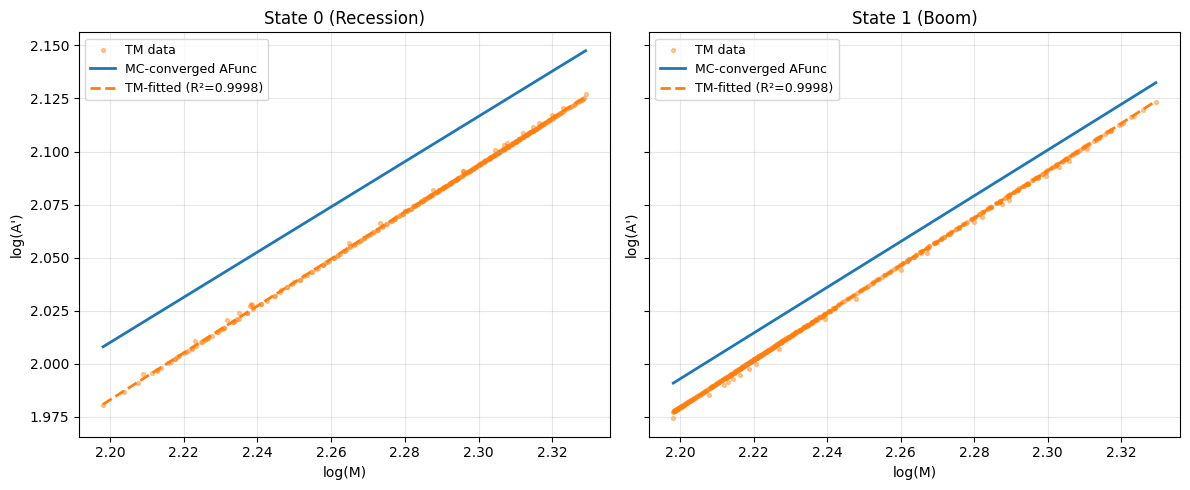

In [17]:
# [fig_afunc_scatter]
fig, axes = plt.subplots(1, StateCount, figsize=(6 * StateCount, 5), sharey=True)
if StateCount == 1:
    axes = [axes]

state_labels = {0: "Recession", 1: "Boom"}
for j in range(StateCount):
    ax = axes[j]
    these = j == MrkvHist_tm
    if np.sum(these) < 10:
        continue

    log_m = logMagg_tm[these]
    log_a = logAagg_tm[these]

    ax.scatter(log_m, log_a, s=8, alpha=0.4, color=COLOR_TM, label="TM data")

    m_range = np.linspace(log_m.min(), log_m.max(), 50)
    ax.plot(
        m_range,
        econ.intercept_prev[j] + econ.slope_prev[j] * m_range,
        color=COLOR_MC,
        linewidth=2,
        label="MC-converged AFunc",
    )

    slope, intercept, r_value, _, _ = sp_stats.linregress(log_m, log_a)
    ax.plot(
        m_range,
        intercept + slope * m_range,
        color=COLOR_TM,
        linewidth=2,
        linestyle="--",
        label=f"TM-fitted (R²={r_value**2:.4f})",
    )

    ax.set_xlabel("log(M)")
    ax.set_ylabel("log(A')")
    ax.set_title(f"State {j} ({state_labels.get(j, '')})")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary

The `make_history_tm()` method forward-propagates a distribution via
transition matrices as an alternative to Monte Carlo in the KS loop.

Key properties:
- **Deterministic**: Zero sampling noise for given aggregate shock sequence.
- **Fast**: Building a 1D TM at each time step via numba is much faster
  than simulating thousands of agents.
- **Compatible**: Produces the same `history` dict as `make_history()`.

**Known limitation**: The TM and MC aggregate trajectories are highly
correlated (>0.99) but exhibit a persistent ~22% level mismatch, with TM
levels systematically lower. This likely stems from differences in
distribution initialization and/or the neutral-measure ↔ level aggregation.
See the investigation note above for details.
